In [ ]:
import pandas as pd

df = pd.read_json("../results/final-gpt.jsonl", lines=True)
df.head(5)

,patient_data,image_path,lab_report,triage_result,diagnose_result,critique_report,final_report,retrieved_cases,trace,ground_truth
0,"{'age': '65', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0028652.jpg,"{'patient_data': {'age': 65, 'sex': 'male', 'l...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Basal cell carcinoma', 'confide...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
1,"{'age': '70', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0029680.jpg,"{'patient_data': {'age': 70, 'sex': 'male', 'l...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Actinic keratosis', 'confidence...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Actinic keratosis', 'conf...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
2,"{'age': '75', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0024411.jpg,"{'patient_data': {'age': 75, 'sex': 'male', 'l...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
3,"{'age': '70', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0028283.jpg,"{'patient_data': {'age': 70, 'sex': 'female', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Basal cell carcinoma', 'confide...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
4,"{'age': '75', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0032414.jpg,"{'patient_data': {'age': 75, 'sex': 'female', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,{'final_diagnosis': 'Pigmented benign keratosi...,[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma


In [25]:
import json
from json.decoder import JSONDecodeError

path = "../results/real-final-gpt.jsonl"

bad = 0
multi = 0

with open(path, "r", encoding="utf-8") as f:
    for lineno, line in enumerate(f, 1):
        s = line.rstrip("\n")
        if not s.strip():
            continue  # skip blank lines

        # Try to parse exactly one JSON value and check for trailing stuff.
        try:
            obj, end = json.JSONDecoder().raw_decode(s)
            rest = s[end:].strip()
            if rest:
                multi += 1
                print(f"[MULTI] line {lineno}: extra data after a valid JSON value -> {rest[:80]!r}")
        except JSONDecodeError as e:
            bad += 1
            snippet = s[max(0, e.pos-40):e.pos+40]
            print(f"[ERROR] line {lineno}: {e.msg} (col {e.colno}) | around: {snippet!r}")

print(f"\nDone. Invalid lines: {bad}, lines with multiple JSON values: {multi}")



Done. Invalid lines: 0, lines with multiple JSON values: 0


In [3]:
df.loc[65, "trace"]

[{'agent': 'lab_technician',
  'role': 'user',
  'payload': {'patient_data': {'age': 60.0,
    'sex': 'male',
    'lesion_location': 'lower extremity',
    'is_melanocytic': True},
   'visual_summary': {'symmetry': 'Symmetrical',
    'colors': ['light brown', 'dark brown', 'tan', 'pink'],
    'border_characteristics': 'Well-defined'},
   'dermoscopic_features': [{'feature_name': 'Clustered brown globules',
     'description': 'Multiple discrete round-to-oval brown globules concentrated centrally. Globules vary in shade from light brown to darker brown and are closely packed in the lesion center.'},
    {'feature_name': 'Central structureless brown area',
     'description': 'A confluent, structureless brown region occupies the core of the lesion, providing a homogeneous background pigment in which individual globules and dots are embedded.'},
    {'feature_name': 'Pigment granularity / dots',
     'description': 'Numerous tiny dark brown to almost black pinpoint dots scattered within t

In [ ]:
from pathlib import Path
import json, re

def clean_raw_json(raw_str):
    cleaned = ''.join(
        c if ord(c) >= 32 and c != '\x7f' else ' '
        for c in raw_str
    )
    
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\n', '\\\\n', cleaned)
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\r', '\\\\r', cleaned)

    # Make sure we didn’t lose the opening {
    stripped = cleaned.strip()
    if not stripped.startswith('{'):
        # Try to find the first '{' and cut everything before it
        pos = cleaned.find('{')
        if pos != -1:
            cleaned = cleaned[pos:]
        else:
            # prepend {
            cleaned = '{' + cleaned

    # Make sure it ends with }
    if not cleaned.strip().endswith('}'):
        pos = cleaned.rfind('}')
        if pos != -1:
            cleaned = cleaned[:pos+1]
        else:
            # Fallback safety
            cleaned = cleaned + '}'

    return cleaned


csv_payload = []
for index, item in df.iterrows():
    trace = item["trace"]
    _retrieved_cases = item["retrieved_cases"]
    retrieved_cases = []
    ground_truth = item["ground_truth"]
    image_path = Path(item["image_path"]).stem
    
    for rc in _retrieved_cases:
        retrieved_cases.append({
            "image_path": Path(rc["image_path"]).stem,
            "age": rc["age"],
            "sex": rc["sex"],
            "diagnosis": rc["diagnosis"],
            "lesion_location": rc["anatom_site"],
            "melanocytic": rc["melanocytic"],
            "sim_score": rc["score"]
        })
    
    dx_agent_payload = next((t for t in trace if t.get("agent") == "synthesizer"), None)
    if not dx_agent_payload:
        csv_payload.append({
            "image_path": image_path,
            "diagnosis": None,
            "reasoning": None,
            "confidence": None,
            "differential": None,
            "ground_truth": ground_truth,
            "retrieved_cases": None,
            "summary": None
        })
        continue

    payload = dx_agent_payload.get("payload", None)
    if not payload:
        # Handle missing payload
        data = {}
    elif isinstance(payload, dict) and '_raw' not in payload:
        # Normal case: already parsed
        data = payload
    elif isinstance(payload, dict) and '_raw' in payload:
        raw_json_str = payload['_raw']
        
        # Clean the problematic string concatenations
        cleaned_str = clean_raw_json(raw_json_str)

        try:
            data = json.loads(cleaned_str)
        except (json.JSONDecodeError, TypeError) as e:
            print(f"Failed to parse cleaned _raw JSON at index {index}: {e}")
            print(f"Raw (cleaned): {cleaned_str[700:750]}...")  # Print context near error
            data = {}
    else:
        data = {}
        
    diagnosis = data.get("final_diagnosis")
    confidence = data.get("confidence")
    differential = data.get("differential_diagnosis")  

    reasoning = data.get("reasoning", {})

    # Append to list
    csv_payload.append({
        "image_path": image_path,
        "diagnosis": diagnosis,
        "ground_truth": ground_truth,
        "confidence": confidence,
        "differential": differential,
        "retrieved_cases": retrieved_cases,
        "reasoning": reasoning
    })


df_payload = pd.DataFrame(csv_payload)

In [27]:
df_payload.head(5)

,image_path,diagnosis,ground_truth,confidence,differential,retrieved_cases,reasoning
0,ISIC_0028652,Basal cell carcinoma,Basal cell carcinoma,Medium,Actinic keratosis (possible progression to squ...,"[{'image_path': 'ISIC_0032132', 'age': 60, 'se...",Both the initial assessment and the critique r...
1,ISIC_0029680,Actinic keratosis,Basal cell carcinoma,Medium,Squamous cell carcinoma,"[{'image_path': 'ISIC_0035308', 'age': 65, 'se...",Both the initial assessment and the critique c...
2,ISIC_0024411,Basal cell carcinoma,Basal cell carcinoma,Medium,Pigmented benign keratosis,"[{'image_path': 'ISIC_0025753', 'age': 70, 'se...",Both the initial proposal (pigmented benign ke...
3,ISIC_0028283,Basal cell carcinoma,Basal cell carcinoma,Medium,Squamous cell carcinoma,"[{'image_path': 'ISIC_0027175', 'age': 70, 'se...",Both arguments have merit. The original assess...
4,ISIC_0032414,Pigmented benign keratosis,Basal cell carcinoma,Medium,Basal cell carcinoma,"[{'image_path': 'ISIC_0027905', 'age': 70, 'se...",Both arguments are plausible. Strengths suppor...


In [28]:
df_payload.isna().sum()

image_path         0
diagnosis          0
ground_truth       0
confidence         0
differential       0
retrieved_cases    0
reasoning          0
dtype: int64

In [29]:
df_payload["diagnosis"].value_counts()

diagnosis
Nevus                         120
Melanoma                       54
Pigmented benign keratosis     41
Basal cell carcinoma           26
Squamous cell carcinoma        24
Actinic keratosis              15
Dermatofibroma                 14
Actinic Keratosis               4
Nevus (atypical/compound)       1
Melanocytic: Melanoma           1
Name: count, dtype: int64

In [30]:
df_payload["ground_truth"].value_counts()

ground_truth
Nevus                         135
Melanoma                       41
Pigmented benign keratosis     40
Basal cell carcinoma           30
Squamous cell carcinoma        23
Dermatofibroma                 16
Actinic Keratosis              15
Name: count, dtype: int64

In [31]:
label_mapping = {
    "Nevus (atypical/compound)": "Nevus",
    "Nevus (atypical/dysplastic nevus)": "Nevus",
    "Melanocytic: Melanoma": "Melanoma",
    "Actinic keratosis": "Actinic Keratosis"
}

def normalize_label(label):
    if isinstance(label, str):
        return label_mapping.get(label.strip(), label.strip())
    return label 

In [32]:
df_payload['diagnosis'] = df_payload['diagnosis'].apply(normalize_label)
df_payload['ground_truth'] = df_payload['ground_truth'].apply(normalize_label)

In [33]:
df_payload["diagnosis"].value_counts()

diagnosis
Nevus                         121
Melanoma                       55
Pigmented benign keratosis     41
Basal cell carcinoma           26
Squamous cell carcinoma        24
Actinic Keratosis              19
Dermatofibroma                 14
Name: count, dtype: int64

In [ ]:
## Initial Diagnosis
df_no_c = pd.read_json("../results/final-gpt.jsonl", lines=True)
df_no_c.head(5)

,patient_data,image_path,lab_report,triage_result,diagnose_result,critique_report,final_report,retrieved_cases,trace,ground_truth
0,"{'age': '65', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0028652.jpg,"{'patient_data': {'age': 65, 'sex': 'male', 'l...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Basal cell carcinoma', 'confide...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
1,"{'age': '70', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0029680.jpg,"{'patient_data': {'age': 70, 'sex': 'male', 'l...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Actinic keratosis', 'confidence...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Actinic keratosis', 'conf...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
2,"{'age': '75', 'sex': 'male', 'lesion_location'...",../dataset/test/ISIC_0024411.jpg,"{'patient_data': {'age': 75, 'sex': 'male', 'l...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
3,"{'age': '70', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0028283.jpg,"{'patient_data': {'age': 70, 'sex': 'female', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Basal cell carcinoma', 'confide...",{'critique_assessment': {'confidence_justified...,"{'final_diagnosis': 'Basal cell carcinoma', 'c...",[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma
4,"{'age': '75', 'sex': 'female', 'lesion_locatio...",../dataset/test/ISIC_0032414.jpg,"{'patient_data': {'age': 75, 'sex': 'female', ...","{'disease_family': 'Keratinocytic', 'confidenc...","{'diagnosis': 'Pigmented benign keratosis', 'c...",{'critique_assessment': {'confidence_justified...,{'final_diagnosis': 'Pigmented benign keratosi...,[{'image_path': '/Users/thinakonelouangdy/Code...,"[{'agent': 'lab_technician', 'role': 'user', '...",Basal cell carcinoma


In [ ]:
from pathlib import Path
import json, re

def clean_raw_json(raw_str):
    cleaned = ''.join(
        c if ord(c) >= 32 and c != '\x7f' else ' '
        for c in raw_str
    )
    
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\n', '\\\\n', cleaned)
    cleaned = re.sub(r'(?<!\\)(?:\\\\)*\r', '\\\\r', cleaned)

    # Make sure we didn’t lose the opening {
    stripped = cleaned.strip()
    if not stripped.startswith('{'):
        # Try to find the first '{' and cut everything before it
        pos = cleaned.find('{')
        if pos != -1:
            cleaned = cleaned[pos:]
        else:
            # prepend {
            cleaned = '{' + cleaned

    # Make sure it ends with }
    if not cleaned.strip().endswith('}'):
        pos = cleaned.rfind('}')
        if pos != -1:
            cleaned = cleaned[:pos+1]
        else:
            # Fallback safety
            cleaned = cleaned + '}'

    return cleaned


csv_payload = []
for index, item in df_no_c.iterrows():
    trace = item["trace"]
    _retrieved_cases = item["retrieved_cases"]
    retrieved_cases = []
    ground_truth = item["ground_truth"]
    image_path = Path(item["image_path"]).stem
    
    for rc in _retrieved_cases:
        retrieved_cases.append({
            "image_path": Path(rc["image_path"]).stem,
            "age": rc["age"],
            "sex": rc["sex"],
            "diagnosis": rc["diagnosis"],
            "lesion_location": rc["anatom_site"],
            "melanocytic": rc["melanocytic"],
            "sim_score": rc["score"]
        })
    
    dx_agent_payload = next((t for t in trace if t.get("agent") == "diagnose"), None)
    if not dx_agent_payload:
        csv_payload.append({
            "image_path": image_path,
            "diagnosis": None,
            "reasoning": None,
            "comparative_analysis": None,
            "confidence": None,
            "differential": None,
            "ground_truth": ground_truth,
            "retrieved_cases": None,
            "summary": None
        })
        continue

    payload = dx_agent_payload.get("payload", None)
    if not payload:
        # Handle missing payload
        data = {}
    elif isinstance(payload, dict) and '_raw' not in payload:
        # Normal case: already parsed
        data = payload
    elif isinstance(payload, dict) and '_raw' in payload:
        raw_json_str = payload['_raw']
        
        # Clean the problematic string concatenations
        cleaned_str = clean_raw_json(raw_json_str)

        try:
            data = json.loads(cleaned_str)
        except (json.JSONDecodeError, TypeError) as e:
            print(f"Failed to parse cleaned _raw JSON at index {index}: {e}")
            print(f"Raw (cleaned): {cleaned_str[700:750]}...")  # Print context near error
            data = {}
    else:
        data = {}
        
    diagnosis = data.get("diagnosis")
    confidence = data.get("confidence")
    differential = data.get("differential_diagnosis")  

    reasoning = data.get("reasoning", {})
    comparative_analysis = reasoning.get("comparative_analysis", [])
    summary = reasoning.get("synthesis", {})
    
    # Append to list
    csv_payload.append({
        "image_path": image_path,
        "diagnosis": diagnosis,
        "reasoning": summary,
        "comparative_analysis": comparative_analysis,
        "ground_truth": ground_truth,
        "confidence": confidence,
        "differential": differential,
        "retrieved_cases": retrieved_cases
    })


df_ini = pd.DataFrame(csv_payload)

In [36]:
df_ini["diagnosis"].value_counts()

diagnosis
Nevus                                       92
Melanoma                                    83
Pigmented benign keratosis                  47
Squamous cell carcinoma                     23
Dermatofibroma                              16
Actinic keratosis                           15
Basal cell carcinoma                        14
Actinic Keratosis                            7
Dermatofibroma (fibrohistiocytic lesion)     1
Dermatofibroma (Fibrohistiocytic)            1
Nevus (atypical/dysplastic nevus)            1
Name: count, dtype: int64

In [37]:
label_mapping = {
    "Nevus (atypical/compound)": "Nevus",
    "Nevus (atypical/dysplastic nevus)": "Nevus",
    "Melanocytic: Melanoma": "Melanoma",
    "Actinic keratosis": "Actinic Keratosis",
    "Dermatofibroma (Fibrohistiocytic)": "Dermatofibroma",
    "Dermatofibroma (fibrohistiocytic lesion)": "Dermatofibroma"
}

def normalize_label(label):
    if isinstance(label, str):
        return label_mapping.get(label.strip(), label.strip())
    return label 

df_ini['diagnosis'] = df_ini['diagnosis'].apply(normalize_label)
df_ini['ground_truth'] = df_ini['ground_truth'].apply(normalize_label)

In [38]:
df_ini.isna().sum()

image_path              0
diagnosis               0
reasoning               0
comparative_analysis    0
ground_truth            0
confidence              0
differential            0
retrieved_cases         0
dtype: int64

In [39]:
y_true = df_payload["ground_truth"]
y_ini_pred = df_ini["diagnosis"]
y_final_pred = df_payload["diagnosis"]

In [40]:
len(y_true), len(y_ini_pred), len(y_final_pred)

(300, 300, 300)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, cohen_kappa_score
import numpy as np

def specificity_multiclass(y_true, y_pred, output_per_class=True):
    cm = confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]
    specificities = []

    # Support: count of true instances per class
    support = cm.sum(axis=1)

    for i in range(n_classes):
        # True Negatives for class i: sum of all cells not in row i or column i
        tn = np.sum(cm[np.arange(n_classes) != i][:, np.arange(n_classes) != i])
        
        # False Positives for class i: sum of column i, excluding diagonal (TP)
        fp = np.sum(cm[:, i]) - cm[i, i]
        
        # Specificity for class i
        specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity_i)
    
    specificities = np.array(specificities)
    
    results = {
        'per_class': specificities.tolist(),
        'macro_avg': np.mean(specificities),
        'weighted_avg': np.average(specificities, weights=support)
    }
    
    return results


ini_spec_per_class = specificity_multiclass(y_true, y_ini_pred)
fin_spec_per_class = specificity_multiclass(y_true, y_final_pred)

# --- Accuracy ---
ini_acc = accuracy_score(y_true, y_ini_pred)

# --- Precision, Recall, F1-Score ---
ini_report = classification_report(y_true, y_ini_pred, digits=4)

# --- Accuracy ---
fin_acc = accuracy_score(y_true, y_final_pred)

# --- Precision, Recall, F1-Score ---
fin_report = classification_report(y_true, y_final_pred, digits=4)

# --- Kappa ---
kappa = cohen_kappa_score(y_true, y_final_pred)

# Recall@K
gt_set = list(y_true)
recall_at_k_score = np.mean([1.0 if gt in [entry['diagnosis'] for entry in sorted(top_k, key=lambda x: x['sim_score'], reverse=True)] else 0.0 for gt, top_k in zip(gt_set, df_payload["retrieved_cases"])])

# Diversity@K
diversity_at_k = np.mean([
    len(set([entry['diagnosis'] for entry in top_k])) / 3 
    for top_k in df["retrieved_cases"]
])

# Count cases where initial was wrong, but final is correct
init_wrong = [(ini, gt, fin) for ini, gt, fin in zip(y_ini_pred, y_true, y_final_pred) if ini != gt]

# Calculate corrected errors (i.e., cases where initial was correct, but final is wrong)
corrected = sum(1 for ini, gt, fin in init_wrong if fin == gt)
corr_err_rate = corrected / len(init_wrong) if init_wrong else float('nan')

# Disagreement rate: Proportion of cases where initial and final diagnosis differ
if not y_ini_pred.empty:
    disagreement_rate = np.mean([1.0 if ini != fin else 0.0 for ini, fin in zip(y_ini_pred, y_final_pred)])
else:
    disagreement_rate = float('nan')
    
    
    
print("Initial Predictions:\n")
print(f"✅ Overall Accuracy: {ini_acc:.4f}\n")
print(f"🔍 Specificity per class: {ini_spec_per_class}")
print("📊 Classification Report:\n", ini_report)
print("\n\nFinal Predictions:\n")
print(f"✅ Overall Accuracy: {fin_acc:.4f}\n")
print(f"🔍 Specificity per class: {fin_spec_per_class}")
print("📊 Classification Report:\n", fin_report)
print(f"✅ Cohen's Kappa: {kappa:.4f}\n")
print(f"✅ Recall@K: {recall_at_k_score:.4f}\n")
print(f"✅ Diversity@K: {diversity_at_k:.4f}\n")
print(f"✅ Corrected-Error Rate: {corr_err_rate:.4f}\n")
print(f"✅ Disagreement Rate: {disagreement_rate:.4f}\n")



Initial Predictions:

✅ Overall Accuracy: 0.6667

🔍 Specificity per class: {'per_class': [0.9543859649122807, 0.9925925925925926, 0.9859154929577465, 0.8223938223938224, 0.9757575757575757, 0.9307692307692308, 0.9530685920577617], 'macro_avg': np.float64(0.944983324491573), 'weighted_avg': np.float64(0.9482166047743438)}
📊 Classification Report:
                             precision    recall  f1-score   support

         Actinic Keratosis     0.4091    0.6000    0.4865        15
      Basal cell carcinoma     0.8571    0.4000    0.5455        30
            Dermatofibroma     0.7778    0.8750    0.8235        16
                  Melanoma     0.4458    0.9024    0.5968        41
                     Nevus     0.9570    0.6593    0.7807       135
Pigmented benign keratosis     0.6170    0.7250    0.6667        40
   Squamous cell carcinoma     0.4348    0.4348    0.4348        23

                  accuracy                         0.6667       300
                 macro avg     0.6427

In [23]:
# temp_df = df_payload[(df_payload["ground_truth"] == "Nevus") & (df_payload["diagnosis"] == "Melanoma")]

# nevus_img = []
# for index, item in temp_df.iterrows():
#     nevus_img.append(Path(item["image_path"]).stem)
    
# print(nevus_img)

df_payload[df_payload["ground_truth"] == "Squamous cell carcinoma"]

,image_path,diagnosis,ground_truth,confidence,differential,retrieved_cases,reasoning
17,ISIC_0026319,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Basal cell carcinoma; Pigmented benign keratosis,"[{'image_path': 'ISIC_0025319', 'age': 80, 'se...","Both reports identify a largely structureless,..."
18,ISIC_0035842,Squamous cell carcinoma,Squamous cell carcinoma,Low,Pigmented benign keratosis,"[{'image_path': 'ISIC_0034015', 'age': 85, 'se...",Both assessments correctly place the lesion in...
19,ISIC_0034427,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Pigmented benign keratosis,"[{'image_path': 'ISIC_0032642', 'age': 50, 'se...",Both arguments have merit. Strengths for SCC: ...
67,ISIC_0024710,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Basal cell carcinoma,"[{'image_path': 'ISIC_0025301', 'age': 70, 'se...",Both the initial assessment and the critique i...
75,ISIC_0029541,Actinic Keratosis,Squamous cell carcinoma,Medium,Pigmented benign keratosis,"[{'image_path': 'ISIC_0030249', 'age': 80, 'se...",Both the initial assessment and the critique i...
79,ISIC_0029573,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Pigmented benign keratosis,"[{'image_path': 'ISIC_0024795', 'age': 55, 'se...",Both the initial assessment and the critique i...
91,ISIC_0025247,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Dermatofibroma (fibrohistiocytic lesion),"[{'image_path': 'ISIC_0028499', 'age': 80, 'se...",Summary of conflict: The initial (Diagnose) ag...
93,ISIC_0026466,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Pigmented benign keratosis,"[{'image_path': 'ISIC_0027023', 'age': 60, 'se...","Both interpretations are plausible, but the cr..."
95,ISIC_0026100,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Basal cell carcinoma,"[{'image_path': 'ISIC_0029567', 'age': 70, 'se...",The original assessment favoring squamous cell...
116,ISIC_0034536,Squamous cell carcinoma,Squamous cell carcinoma,Medium,Pigmented benign keratosis (seborrheic/benign ...,"[{'image_path': 'ISIC_0030191', 'age': 60, 'se...",Summary of the conflict: The Diagnose agent fa...


In [59]:
df_payload[(df_payload["ground_truth"] == "Nevus") & (df_payload["diagnosis"] == "Melanoma")]
# df_payload[df_payload["ground_truth"] == "Actinic Keratosis"]

,image_path,diagnosis,ground_truth,confidence,differential,retrieved_cases,reasoning
63,ISIC_0025686,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0024307', 'age': 50, 'se...",The initial assessment favoring a nevus relied...
222,ISIC_0032239,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0030780', 'age': 45, 'se...",Both arguments raise valid points. The origina...
225,ISIC_0024692,Melanoma,Nevus,Low,Nevus,"[{'image_path': 'ISIC_0028396', 'age': 65, 'se...",Both the initial proposal and the critique agr...
227,ISIC_0031079,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0028524', 'age': 25, 'se...",Both reports agree the lesion is melanocytic. ...
228,ISIC_0024560,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0035009', 'age': 35, 'se...",Both assessments agree the lesion is melanocyt...
231,ISIC_0028092,Melanoma,Nevus,Low,Nevus,"[{'image_path': 'ISIC_0030061', 'age': 45, 'se...",Both assessments agree the lesion is melanocyt...
235,ISIC_0027764,Melanoma,Nevus,High,Nevus,"[{'image_path': 'ISIC_0032470', 'age': 40, 'se...",Both reports agree the lesion is melanocytic w...
236,ISIC_0034130,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0032289', 'age': 40, 'se...",The initial assessment favored an atypical nev...
238,ISIC_0028738,Melanoma,Nevus,Medium,Nevus,"[{'image_path': 'ISIC_0026718', 'age': 55, 'se...",Both reports agree the lesion is melanocytic a...
240,ISIC_0025658,Melanoma,Nevus,Low,Nevus,"[{'image_path': 'ISIC_0027110', 'age': 65, 'se...",Both the original assessment and the critique ...


## Plot Confusion Matrix

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_labels, title='Confusion Matrix', figsize=(10, 8)):
    """
    Generates and plots a confusion matrix.

    Args:
        y_true (array-like): Ground truth (correct) labels.
        y_pred (array-like): Predicted labels, as returned by a classifier.
        class_labels (list): A list of labels to index the matrix.
        title (str): The title for the plot.
        figsize (tuple): The figure size for the plot.
    """
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=figsize)
    
    sns.heatmap(cm, 
                annot=True,        
                fmt='d',           
                cmap='Blues',      
                xticklabels=class_labels,
                yticklabels=class_labels)
    
    plt.xlabel('Predicted Label', fontsize=13)
    plt.ylabel('True Label', fontsize=13)
    plt.title(title, fontsize=16)
    
    plt.show()

Displaying Confusion Matrix for Initial Diagnosis...


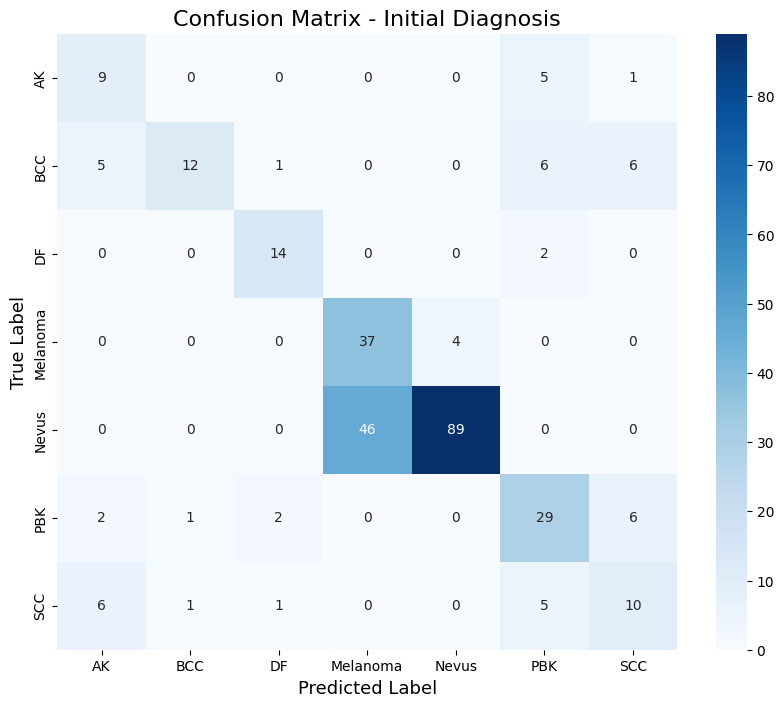


Displaying Confusion Matrix for Final Diagnosis...


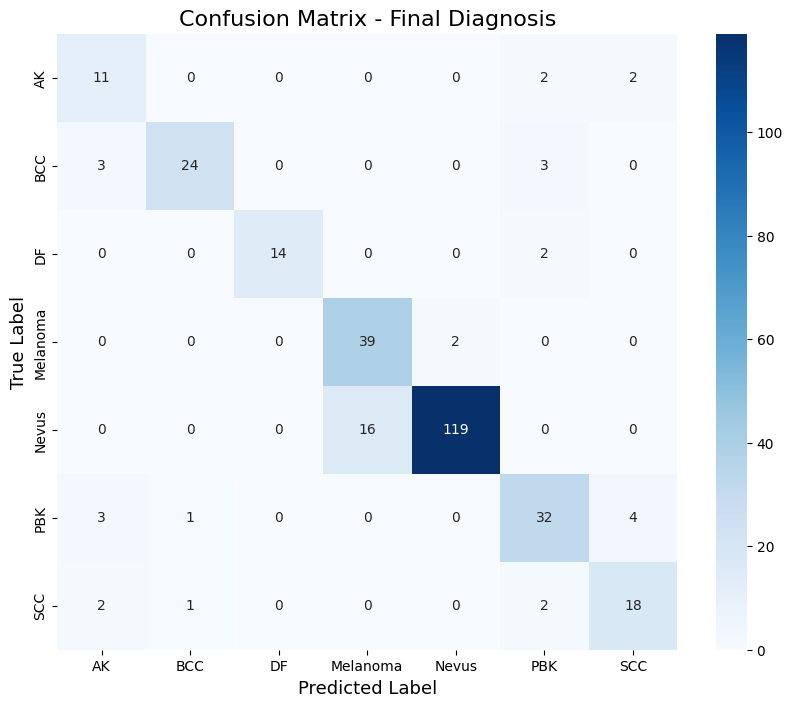

In [21]:
class_labels = ['AK', 'BCC', 'DF', 'Melanoma', 'Nevus', 'PBK', 'SCC']
# 1. Plot the confusion matrix for the INITIAL diagnosis
print("Displaying Confusion Matrix for Initial Diagnosis...")
plot_confusion_matrix(y_true, 
                      y_ini_pred, 
                      class_labels=class_labels, 
                      title='Confusion Matrix - Initial Diagnosis')


# 2. Plot the confusion matrix for the FINAL diagnosis
print("\nDisplaying Confusion Matrix for Final Diagnosis...")
plot_confusion_matrix(y_true, 
                      y_final_pred, 
                      class_labels=class_labels, 
                      title='Confusion Matrix - Final Diagnosis')

In [42]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from itertools import product

# y_true, y_init, y_final are integer arrays of length 300 in [0..6]
K = 7
init_ok  = (y_ini_pred == y_true)
final_ok = (y_final_pred == y_true)

# Overall McNemar
a = int(np.sum(init_ok & final_ok))
b = int(np.sum(init_ok & ~final_ok))
c = int(np.sum(~init_ok & final_ok))
d = int(np.sum(~init_ok & ~final_ok))
res_overall = mcnemar([[a,b],[c,d]], exact=(b+c<25), correction=(b+c>=25))

# Paired OR (+ 0.5 if zero)
b_ = b if b>0 else 0.5
c_ = c if c>0 else 0.5
or_overall = b_/c_

# Per-class McNemar (recall deltas)
per_class = []
pvals = []
for k in range(K):
    idx = (y_true == k)
    if idx.sum() == 0:
        per_class.append({"k": k, "n_true": 0, "p": 1.0})
        pvals.append(1.0)
        continue
    init_hit  = (y_ini_pred[idx]  == k)
    final_hit = (y_final_pred[idx] == k)
    a_k = int(np.sum(init_hit & final_hit))
    b_k = int(np.sum(init_hit & ~final_hit))   # lost a TP
    c_k = int(np.sum(~init_hit & final_hit))   # gained a TP
    d_k = int(np.sum(~init_hit & ~final_hit))
    res_k = mcnemar([[a_k,b_k],[c_k,d_k]], exact=(b_k+c_k<25), correction=(b_k+c_k>=25))
    per_class.append({"k": k, "n_true": int(idx.sum()), "a": a_k, "b": b_k, "c": c_k, "d": d_k,
                      "p": res_k.pvalue})
    pvals.append(res_k.pvalue)

# Holm adjustment
order = np.argsort(pvals)
adj = [None]*K
m = K
running = 0.0
for rank, i in enumerate(order, 1):
    adj_p = pvals[i] * (m - rank + 1)
    running = max(running, adj_p)
    adj[i] = min(1.0, running)
for r in per_class:
    r["p_holm"] = adj[r["k"]]


In [43]:
# After you computed a,b,c,d and res_overall:
print("OVERALL (accuracy improvement)")
print(f"a={a}, b={b}, c={c}, d={d}, n={a+b+c+d}")
print(f"discordant b+c = {b+c}")
print(f"McNemar statistic = {res_overall.statistic:.4f}")
print(f"p-value = {res_overall.pvalue:.6f}")
print(f"paired OR (b/c) = {or_overall:.3f}")
if c > b and res_overall.pvalue < 0.05:
    print("⇒ Significant improvement (final fixes more errors than it introduces).")
elif b > c and res_overall.pvalue < 0.05:
    print("⇒ Significant degradation (final introduces more errors).")
else:
    print("⇒ No significant change.")

OVERALL (accuracy improvement)
a=187, b=13, c=70, d=30, n=300
discordant b+c = 83
McNemar statistic = 37.7831
p-value = 0.000000
paired OR (b/c) = 0.186
⇒ Significant improvement (final fixes more errors than it introduces).
